<a href="https://colab.research.google.com/github/manuela1702/elephant_migration/blob/main/elephant_migration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# imports
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

# connecting to Google Drive
drive.mount('/content/drive')

# loading dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/African elephants.csv')

# overview of the first lines
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(99988, 10)


,event-id,visible,timestamp,location-long,location-lat,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name
0,7980499272,True,2008-10-30 00:15:00.000,16.202088,-19.063725,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
1,7980499273,True,2008-10-30 02:46:00.000,16.209496,-19.069908,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
2,7980499274,True,2008-10-30 03:31:00.000,16.214184,-19.068719,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
3,7980499275,True,2008-10-30 03:45:00.000,16.214170,-19.068683,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...
4,7980499276,True,2008-10-30 05:31:00.000,16.229372,-19.058258,gps,Loxodonta africana,AG005,LA5,African elephants in Etosha National Park (dat...


In [19]:
# Select only needed columns
df = df[['timestamp', 'location-lat', 'location-long', 'individual-local-identifier']]

# Rename columns for easier use
df.columns = ['timestamp', 'lat', 'lon', 'elephant_id']

# Convert timestamp string to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Remove rows with missing values
df = df.dropna()

# Verify result
print(df.shape)
df.head()

(99988, 4)


,timestamp,lat,lon,elephant_id
0,2008-10-30 00:15:00,-19.063725,16.202088,LA5
1,2008-10-30 02:46:00,-19.069908,16.209496,LA5
2,2008-10-30 03:31:00,-19.068719,16.214184,LA5
3,2008-10-30 03:45:00,-19.068683,16.214170,LA5
4,2008-10-30 05:31:00,-19.058258,16.229372,LA5


In [20]:
# Extract month and year from timestamp
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

# Add season - Namibia has 2 seasons:
# Wet season: November - April (months 11,12,1,2,3,4)
# Dry season: May - October (months 5,6,7,8,9,10)
df['season'] = df['month'].apply(lambda x: 'wet' if x in [11,12,1,2,3,4] else 'dry')

# Verify
print(df['season'].value_counts())
df.head()

season
wet    52145
dry    47843
Name: count, dtype: int64


,timestamp,lat,lon,elephant_id,month,year,season
0,2008-10-30 00:15:00,-19.063725,16.202088,LA5,10,2008,dry
1,2008-10-30 02:46:00,-19.069908,16.209496,LA5,10,2008,dry
2,2008-10-30 03:31:00,-19.068719,16.214184,LA5,10,2008,dry
3,2008-10-30 03:45:00,-19.068683,16.214170,LA5,10,2008,dry
4,2008-10-30 05:31:00,-19.058258,16.229372,LA5,10,2008,dry


In [21]:
# Haversine formula - calculates distance between two GPS points in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Sort by elephant and time
df = df.sort_values(['elephant_id', 'timestamp']).reset_index(drop=True)

# Calculate distance between each two consecutive points
df['dist_km'] = haversine(
    df['lat'], df['lon'],
    df['lat'].shift(1), df['lon'].shift(1)
)

# First point of each elephant has no previous point - set to 0
df.loc[df.groupby('elephant_id').head(1).index, 'dist_km'] = 0

# Verify
df[['timestamp', 'elephant_id', 'dist_km']].head(10)

,timestamp,elephant_id,dist_km
0,2008-10-30 02:20:00,LA1,0.000000
1,2008-10-30 04:01:00,LA1,0.140495
2,2008-10-30 07:40:00,LA1,0.702356
3,2008-10-30 11:01:00,LA1,0.304426
4,2008-10-30 11:40:00,LA1,0.533835
5,2008-10-30 12:05:00,LA1,0.257711
6,2008-10-30 14:21:00,LA1,0.311427
7,2008-10-30 16:20:00,LA1,0.636441
8,2008-10-30 18:21:00,LA1,1.609245
9,2008-10-30 19:40:00,LA1,1.165322


In [22]:
# Add date column without time
df['date'] = df['timestamp'].dt.date

# Group by elephant and day - sum all distances for that day
daily = df.groupby(['elephant_id', 'date', 'season', 'month'])['dist_km'].sum().reset_index()
daily.columns = ['elephant_id', 'date', 'season', 'month', 'daily_km']

# Verify
print(daily.shape)
daily.head(10)

(10619, 5)


,elephant_id,date,season,month,daily_km
0,LA1,2008-10-30,dry,10,9.877060
1,LA1,2008-10-31,dry,10,12.863060
2,LA1,2008-11-01,wet,11,13.328596
3,LA1,2008-11-02,wet,11,10.375661
4,LA1,2008-11-03,wet,11,13.112730
5,LA1,2008-11-04,wet,11,14.884745
6,LA1,2008-11-05,wet,11,9.490410
7,LA1,2008-11-06,wet,11,7.270835
8,LA1,2008-11-07,wet,11,3.704351
9,LA1,2008-11-08,wet,11,17.563685


  season   daily_km
0    dry  10.234006
1    wet  11.392511


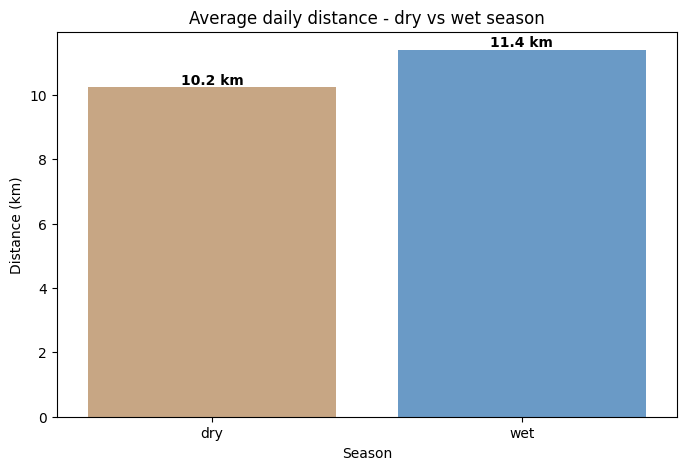

In [25]:
# Average daily distance by season
season_avg = daily.groupby('season')['daily_km'].mean().reset_index()
print(season_avg)

# Bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    data=season_avg,
    x='season',
    y='daily_km',
    hue='season',
    palette={'dry': '#D2A679', 'wet': '#5B9BD5'},
    legend=False
)
plt.title('Average daily distance - dry vs wet season')
plt.xlabel('Season')
plt.ylabel('Distance (km)')

# Add value labels on bars
for i, row in season_avg.iterrows():
    plt.text(i, row['daily_km'] + 0.1, f"{row['daily_km']:.1f} km",
             ha='center', fontweight='bold')

plt.show()

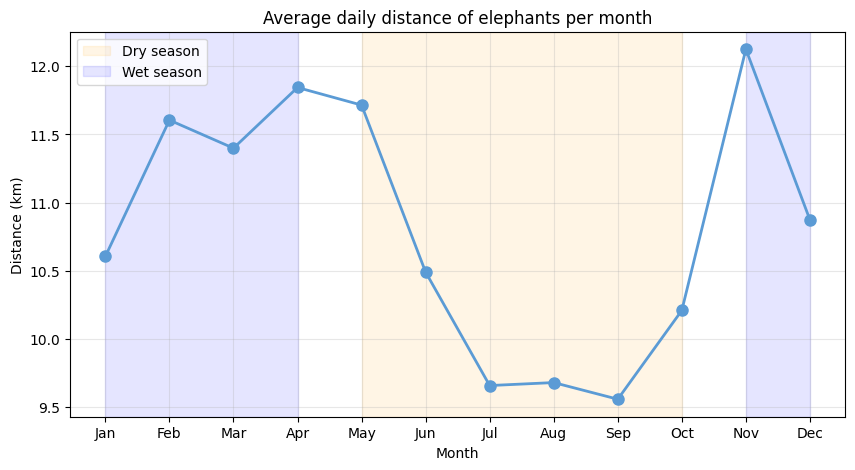

In [24]:
# Average daily distance per month
monthly_avg = daily.groupby('month')['daily_km'].mean().reset_index()

# Month names
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_avg['month_name'] = monthly_avg['month'].map(months)

# Line chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg['month'], monthly_avg['daily_km'],
         marker='o', color='#5B9BD5', linewidth=2, markersize=8)

# Mark seasons with background color
plt.axvspan(5, 10, alpha=0.1, color='orange', label='Dry season')
plt.axvspan(1, 4, alpha=0.1, color='blue', label='Wet season')
plt.axvspan(11, 12, alpha=0.1, color='blue')

plt.xticks(monthly_avg['month'], monthly_avg['month_name'])
plt.title('Average daily distance of elephants per month')
plt.xlabel('Month')
plt.ylabel('Distance (km)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()